# Data Augumentation Chapter 9 Workshop 3

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, AvgPool2D

## Define path and data size

In [51]:
train_dir = './datasets/train_set'
val_dir = './datasets/val_set'
target_size = (64, 64)

## Prepare Data Augumentation

### create train datasets

In [3]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=20,       # rotate image  +- 20 degrees
                                   height_shift_range=0.2,  # shift image up/down
                                   width_shift_range=0.2,   # shift image left/right
                                   shear_range=0.9,         # shear image (การเฉือน)
                                   zoom_range=0.2,          # zoom in/out
                                   horizontal_flip=True,    # flip image horizontally
                                   fill_mode='nearest')     # fill in the blank space after rotation

train_set = train_datagen.flow_from_directory(train_dir,
                                               target_size=target_size,
                                               batch_size=32,
                                               class_mode='binary')  # binary classification



Found 15997 images belonging to 2 classes.


### create validation datasets

In [52]:
val_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=20,       # rotate image  +- 20 degrees
                                   height_shift_range=0.2,  # shift image up/down
                                   width_shift_range=0.2,   # shift image left/right
                                   shear_range=0.9,         # shear image (การเฉือน)
                                   zoom_range=0.2,          # zoom in/out
                                   horizontal_flip=True,    # flip image horizontally
                                   fill_mode='nearest')     # fill in the blank space after rotation

val_set = val_datagen.flow_from_directory(val_dir,
                                               target_size=target_size,
                                               batch_size=32,
                                               class_mode='binary')  # binary classification



Found 2000 images belonging to 2 classes.


## Visualize data

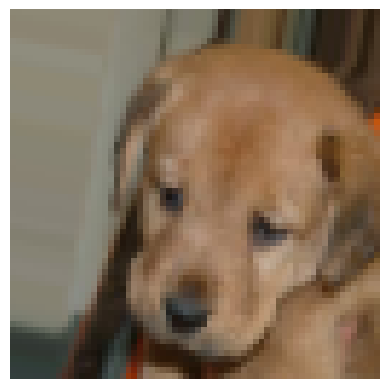

In [40]:
plt.imshow(train_set[2][0][1])  # show the first image in the batch
plt.axis('off')                 # turn off axis
plt.show()                      # display the image

# train_set[<batch number>][0][<image number>]

## Define input shape

In [53]:
img = train_set[0][0][0]
in_shape = (img.shape[0], img.shape[1], 3)
print('in_shape: ', in_shape) # (64, 64, 3)

in_shape:  (64, 64, 3)


## Create model

In [54]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=in_shape))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

d:\Programming_File\Environment\tf\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

## Compile model

In [55]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

## Traning model

In [56]:
import time
start = time.time()

history = model.fit(train_set,
                    steps_per_epoch=len(train_set),
                    epochs=20,
                    validation_data=val_set,
                    verbose=1)

end = time.time()
print('Time taken to train the model: ', (end-start)/60, 'minutes')

Epoch 1/20


d:\Programming_File\Environment\tf\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


500/500 ━━━━━━━━━━━━━━━━━━━━ 145s 288ms/step - accuracy: 0.5493 - loss: 0.6818 - val_accuracy: 0.5835 - val_loss: 0.6513
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 59s 118ms/step - accuracy: 0.6493 - loss: 0.6220 - val_accuracy: 0.6870 - val_loss: 0.5911
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 117ms/step - accuracy: 0.6921 - loss: 0.5842 - val_accuracy: 0.7325 - val_loss: 0.5388
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 113ms/step - accuracy: 0.7243 - loss: 0.5467 - val_accuracy: 0.7570 - val_loss: 0.5173
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 114ms/step - accuracy: 0.7383 - loss: 0.5230 - val_accuracy: 0.7665 - val_loss: 0.4845
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 57s 115ms/step - accuracy: 0.7611 - loss: 0.4945 - val_accuracy: 0.7640 - val_loss: 0.4932
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 115ms/step - accuracy: 0.7749 - loss: 0.4708 - val_accuracy: 0.7795 - val_loss: 0.4641
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 116ms/step - accuracy: 0.7829 - loss: 0.4567 - va

## Loss and Accuracy Curve

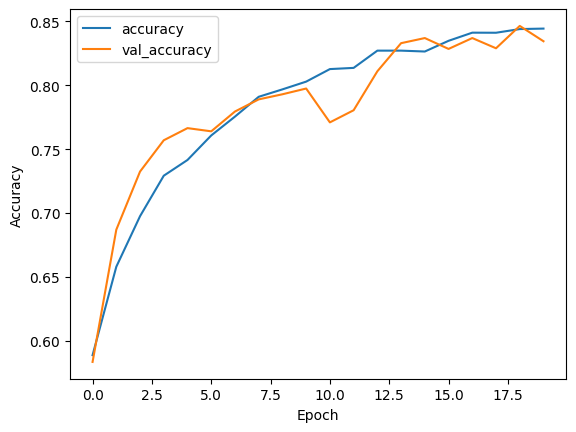

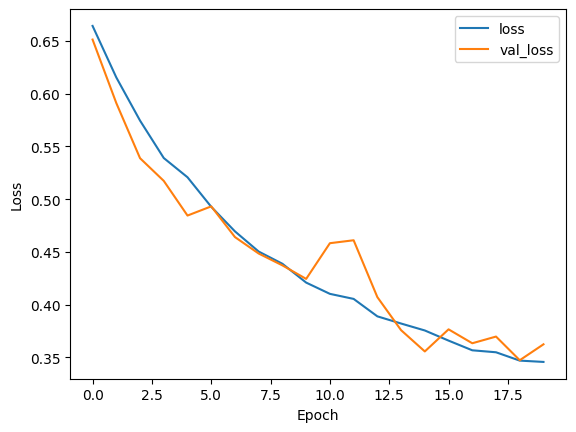

In [57]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Evaluate model

In [58]:
score = model.evaluate(val_set, verbose=0)
# print('Test loss:', score[0])
print('Test accuracy:', round(score[1],3))

Test accuracy: 0.837


## Save model

In [ ]:
# model.save('./model/cat_dog_classification_data_augumentation_model.h5')